In [1]:
!pip install -q ydata-profiling

You should consider upgrading via the 'D:\Emersion\GEN_AI_WORKSHOP\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
df = pd.read_csv('D:\Emersion\GEN_AI_WORKSHOP\ecommerce_500k.csv')

In [4]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Ecommerce Churn Dataset Profiling Report",
    explorative=True
)

In [5]:
profile.to_file("dataset_profile_report.html")

Summarize dataset:   0%|          | 0/35 [00:00<?, ?it/s, Describe variable: order_id]

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 20.67it/s]


In [8]:
return_analysis = pd.crosstab(
    df['loyalty_tier'],
    df['is_returned'],
    normalize='index'
) * 100

print(return_analysis)

is_returned           0          1
loyalty_tier                      
Bronze        87.971328  12.028672
Gold          88.017194  11.982806
Platinum      88.040209  11.959791
Silver        88.086599  11.913401


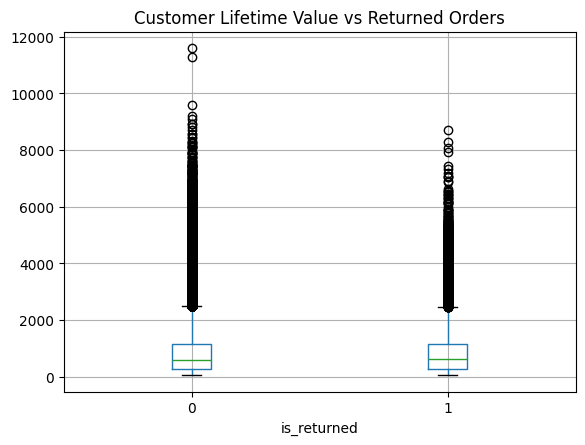

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
df.boxplot(column='customer_lifetime_value', by='is_returned')
plt.title('Customer Lifetime Value vs Returned Orders')
plt.suptitle('')
plt.show()

In [15]:
print(df.head())
print(df.info())
print(df.describe())

print(df.isnull().sum())

print(df['is_returned'].value_counts())

print(df.groupby('loyalty_tier')['is_returned'].mean())

print(df.sort_values('is_returned', ascending=False).head())

   order_id  customer_id  product_id  order_date    category sub_category  \
0   1000001        25795          90  2022-07-31    Clothing          Men   
1   1000002        10860        1917  2023-09-25  Automotive     Car Care   
2   1000003        86820         805  2022-03-26       Books    Textbooks   
3   1000004        64886        3379  2022-11-03       Books  Non-Fiction   
4   1000005        16265        4604  2022-06-30    Clothing        Women   

   product_base_price  discount_percentage  final_price  quantity  ...  \
0               70.41                   25        52.81         1  ...   
1                6.02                   10         5.42         3  ...   
2               78.85                   20        63.08         2  ...   
3               58.42                   25        43.82         4  ...   
4               73.38                   15        62.37         1  ...   

         city  loyalty_tier is_first_purchase  customer_lifetime_value  \
0   Bangalore     

In [16]:
print(df.columns)

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'category',
       'sub_category', 'product_base_price', 'discount_percentage',
       'final_price', 'quantity', 'total_amount', 'shipping_cost',
       'shipping_method', 'days_to_deliver', 'payment_method', 'rating',
       'num_reviews', 'customer_age', 'customer_gender', 'country', 'city',
       'loyalty_tier', 'is_first_purchase', 'customer_lifetime_value',
       'session_duration_mins', 'pages_viewed', 'clicks_to_purchase',
       'is_returned', 'return_reason', 'is_cancelled'],
      dtype='object')


In [17]:
contract_churn = df.groupby('loyalty_tier')['is_returned'].value_counts()
print(contract_churn)

loyalty_tier  is_returned
Bronze        0              197961
              1               27068
Gold          0               74944
              1               10203
Platinum      0               35121
              1                4771
Silver        0              132070
              1               17862
Name: count, dtype: int64


In [18]:
contract_churn_rate = df.groupby('loyalty_tier')['is_returned'].apply(
    lambda x: (x == 1).mean() * 100
)

print(contract_churn_rate)

loyalty_tier
Bronze      12.028672
Gold        11.982806
Platinum    11.959791
Silver      11.913401
Name: is_returned, dtype: float64


In [20]:
payment_churn = df.groupby('payment_method')['is_returned'].apply(
    lambda x: (x == 1).mean() * 100
).sort_values(ascending=False)

print(payment_churn)

payment_method
Wallet         12.052046
COD            12.035979
UPI            12.028366
Credit Card    12.005766
Net Banking    11.878894
Debit Card     11.861737
Name: is_returned, dtype: float64


In [24]:
pivot = pd.pivot_table(
    df,
    index='customer_gender',
    columns='loyalty_tier',
    values='customer_id',
    aggfunc='count'
)

print(pivot)

loyalty_tier     Bronze   Gold  Platinum  Silver
customer_gender                                 
Female           110002  41778     19500   73312
Male             108390  40754     19181   72009
Other              6637   2615      1211    4611


In [25]:
pivot_churn = pd.pivot_table(
    df[df['is_returned'] == 1],
    index='customer_gender',
    columns='loyalty_tier',
    values='customer_id',
    aggfunc='count',
    fill_value=0
)

print(pivot_churn)

loyalty_tier     Bronze  Gold  Platinum  Silver
customer_gender                                
Female            13268  4998      2379    8732
Male              12980  4889      2261    8571
Other               820   316       131     559
